# **Fault Detection**

### **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r'..\data\raw\ENV_data_2025-06-16_to_2025-06-22.csv')

df

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-16 11:07:01+07:00,25.7,84.6,24.2,35.9,NaN,NaN
1,2025-06-17 14:02:31+07:00,25.9,73.6,23.1,32.3,NaN,NaN
2,2025-06-17 14:03:21+07:00,25.9,73.4,25.3,35.9,NaN,NaN
3,2025-06-17 14:04:10+07:00,25.9,72.9,25.7,36.2,NaN,NaN
4,2025-06-17 14:04:59+07:00,25.9,74.4,26.6,35.3,NaN,NaN
...,...,...,...,...,...,...,...
7757,2025-06-22 06:56:14+07:00,25.1,90.0,73.4,100.3,0.53338,404.14658
7758,2025-06-22 06:57:03+07:00,25.2,88.9,79.7,111.2,0.55777,404.04834
7759,2025-06-22 06:57:53+07:00,25.2,88.5,84.1,115.3,0.55777,403.86526
7760,2025-06-22 06:58:42+07:00,25.2,88.5,82.1,111.2,0.58302,403.80316


In [14]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,CO,CO2
count,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,26.758904,78.613694,43.242012,57.000129,1.881124,403.906187
std,1.112280,5.291232,38.345703,48.762572,1.230806,0.860725
min,24.100000,64.000000,8.700000,10.900000,0.370100,400.787660
25%,26.000000,75.100000,16.400000,21.900000,0.614490,403.293330
50%,26.700000,78.300000,30.400000,43.300000,1.588430,403.719120
75%,27.600000,81.100000,57.000000,72.650000,2.768360,404.247010
max,29.600000,91.600000,778.099980,862.500000,6.114610,409.802520


In [21]:
df.loc[df['PM2.5'] > 150]  # Filter semua baris dengan PM2.5 > 100

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
234,2025-06-17 17:22:51+07:00,27.9,74.1,158.89999,181.20000,2.04066,403.93002
235,2025-06-17 17:23:40+07:00,28.0,74.5,162.30000,188.50000,2.26174,403.91583
236,2025-06-17 17:24:30+07:00,28.0,74.8,164.10001,190.89999,2.05010,403.98718
237,2025-06-17 17:25:19+07:00,28.0,74.6,170.00000,198.20000,2.10747,403.93002
238,2025-06-17 17:26:09+07:00,28.0,74.4,186.39999,212.39999,2.28230,404.02325
239,2025-06-17 17:26:58+07:00,28.0,74.6,188.30000,215.10001,2.28746,403.92291
240,2025-06-17 17:27:48+07:00,28.0,75.5,173.60001,201.30000,2.04066,403.93713
241,2025-06-17 17:28:37+07:00,28.0,75.8,167.50000,193.60001,2.05010,404.03778
242,2025-06-17 17:29:26+07:00,28.0,76.0,163.50000,190.50000,2.25662,403.98718
243,2025-06-17 17:30:16+07:00,28.0,75.9,155.00000,181.50000,2.17604,404.04504


## **Preprocessing**

In [3]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             7
CO2            7
dtype: int64

In [4]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [5]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [9]:
df.head()

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
7,2025-06-17 14:08:50+07:00,25.9,71.3,26.4,35.1,1.32246,402.82861
8,2025-06-17 14:09:40+07:00,25.9,70.1,26.2,33.3,1.28997,402.73026
9,2025-06-17 14:10:36+07:00,25.9,69.7,24.5,32.5,1.31978,402.81689
10,2025-06-17 14:11:26+07:00,25.9,69.3,24.1,31.9,1.32873,402.75455
11,2025-06-17 14:12:15+07:00,25.8,69.1,25.1,32.0,1.30203,402.64542


In [8]:
scaler = StandardScaler()
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']
X = df[features]

X_scaled = scaler.fit_transform(X)

## **Clustering**

In [7]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

**KMEANS**

In [10]:
# Clustering dengan KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluasi dan deteksi outlier
df_kmeans = df.copy()
df_kmeans['kmeans_cluster'] = kmeans_labels
minority_cluster = df_kmeans['kmeans_cluster'].value_counts().idxmin()
df_kmeans['kmeans_outlier'] = df_kmeans['kmeans_cluster'] == minority_cluster
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("KMeans Silhouette Score:", round(kmeans_silhouette, 3))
print("KMeans - Jumlah outlier:", df_kmeans['kmeans_outlier'].sum())

KMeans Silhouette Score: 0.401
KMeans - Jumlah outlier: 2368


In [12]:
# Clustering dengan DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['dbscan_cluster'] = dbscan_labels
df_dbscan['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_dbscan['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")


DBSCAN - Jumlah cluster: 4
DBSCAN - Jumlah outlier: 159
DBSCAN Silhouette Score: 0.285


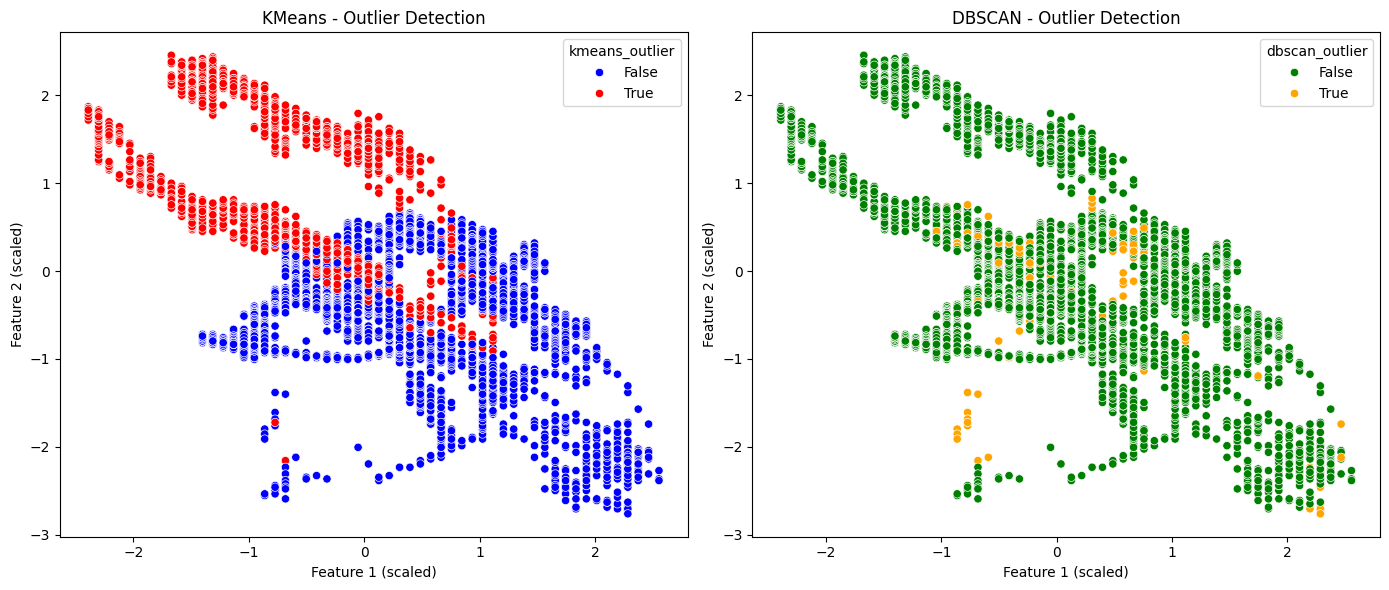

In [13]:
plt.figure(figsize=(14, 6))

# Visualisasi KMeans
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1],
                hue=df_kmeans['kmeans_outlier'],
                palette={False: 'blue', True: 'red'})
plt.title('KMeans - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

# Visualisasi DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1],
                hue=df_dbscan['dbscan_outlier'],
                palette={False: 'green', True: 'orange'})
plt.title('DBSCAN - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

plt.tight_layout()
plt.show()


**Hyperparameter Tuning**

In [ ]:
from tqdm.notebook import tqdm

best_k = None
best_score_k = -1
silhouette_scores_k = []

print("Grid Search KMeans:")
for k in tqdm(range(2, 10)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_k.append((k, score))
    
    if score > best_score_k:
        best_k = k
        best_score_k = score

print(f"Best K: {best_k}, Silhouette Score: {round(best_score_k, 4)}")